<a href="https://colab.research.google.com/github/MsSaidat25/AI-Engineer-Projects/blob/main/ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install statsmodels

In [23]:
!wget -nc https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv

File ‘airline-passengers.csv’ already there; not retrieving.



In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv('airline-passengers.csv', index_col='Month', parse_dates=True)

In [26]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


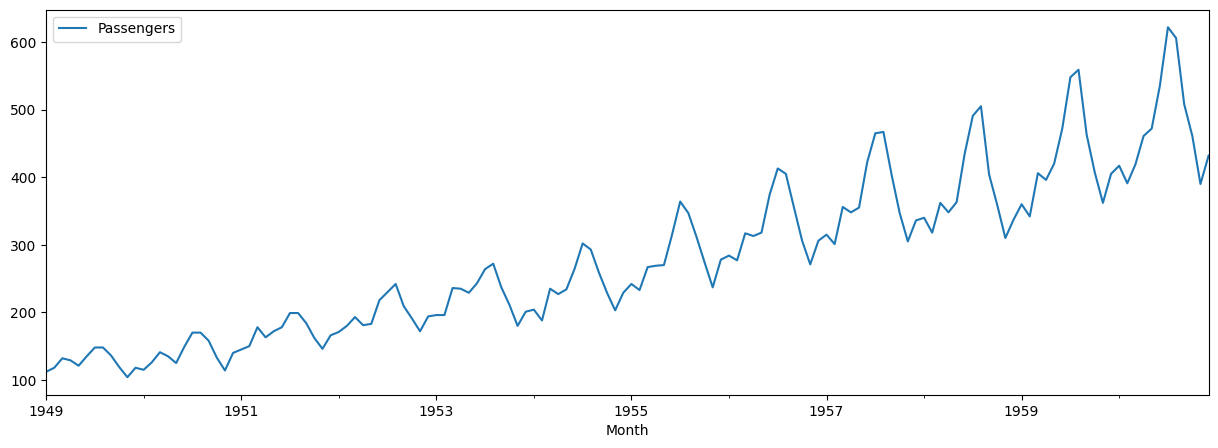

In [27]:
df.plot(figsize=(15, 5));

In [28]:
df['1stdiff'] = df['Passengers'].diff()

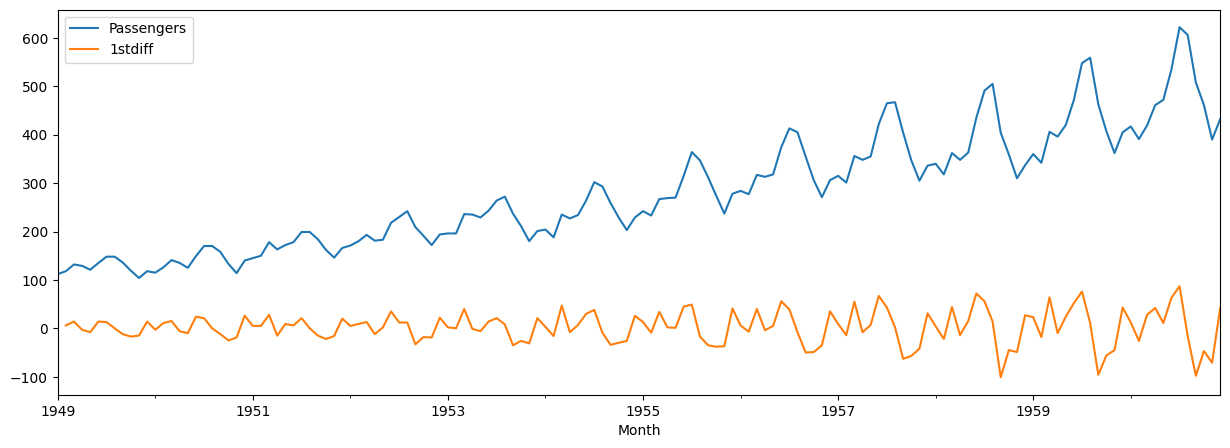

In [29]:
df.plot(figsize=(15, 5));

In [30]:
df['LogPassengers'] = np.log(df['Passengers'])

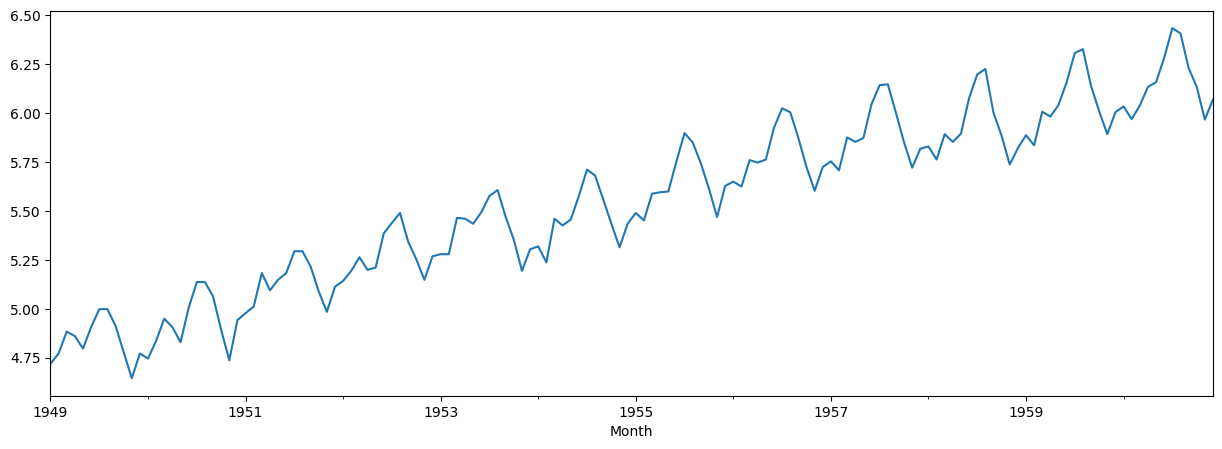

In [31]:
df['LogPassengers'].plot(figsize=(15, 5));

In [32]:
from statsmodels.tsa.arima.model import ARIMA

In [33]:
df.index.freq = 'MS'

Ntest = 12
train = df.iloc[:-Ntest]
test = df.iloc[-Ntest:]

In [34]:
train_idx = df.index <=train.index[-1]
test_idx = df.index > train.index[-1]

In [35]:
arima = ARIMA(train['Passengers'], order=(1,1,1))

In [36]:
arima_result = arima.fit()

In [37]:
df.loc[train_idx, 'AR(1)'] = arima_result.predict(
    start=train.index[0],
    end=train.index[-1]
)

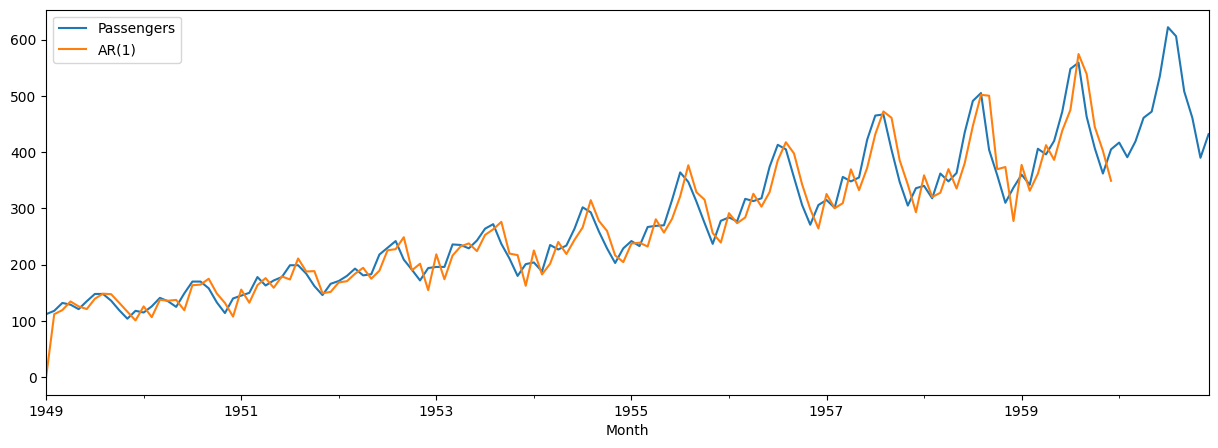

In [38]:
df[['Passengers', 'AR(1)']].plot(figsize=(15, 5));

In [39]:
prediction_result = arima_result.get_forecast(Ntest)
forecast = prediction_result.predicted_mean
df.loc[test_idx, 'AR(1)'] = forecast

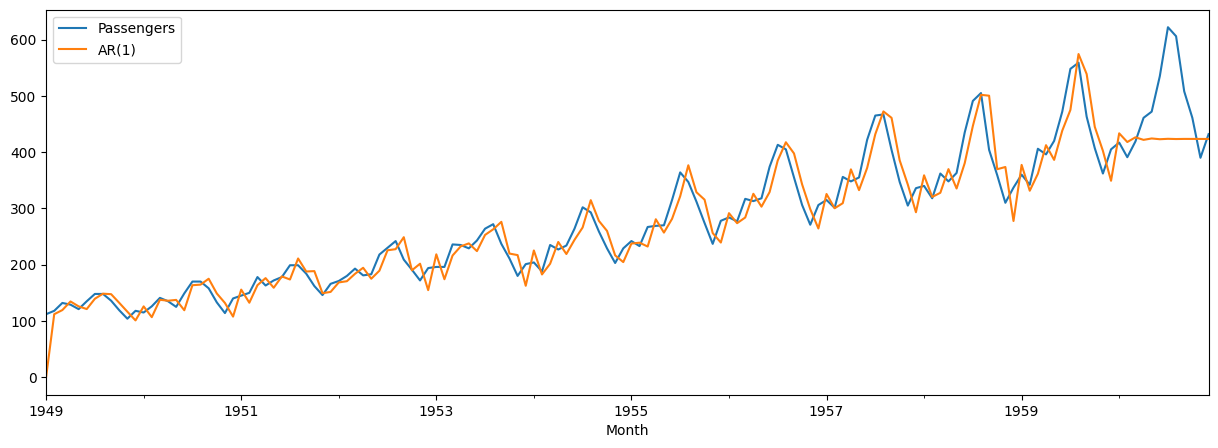

In [40]:
df[['Passengers', 'AR(1)']].plot(figsize=(15, 5));

In [41]:
# Explore prediction result further
type(prediction_result)

statsmodels.tsa.statespace.mlemodel.PredictionResultsWrapper

In [42]:
# Confidence interval
prediction_result.conf_int()

,lower Passengers,upper Passengers
1960-01-01,377.445641,489.458213
1960-02-01,322.373309,513.595133
1960-03-01,310.322096,542.464182
1960-04-01,285.148421,558.494950
1960-05-01,271.334994,577.278859
1960-06-01,254.484358,591.427325
1960-07-01,241.421624,605.959076
1960-08-01,227.999952,618.582126
1960-09-01,216.112039,630.904204
1960-10-01,204.505257,642.274956


In [43]:
def plot_fit_and_forecast(result):
  fig, ax = plt.subplots(figsize=(15, 5))
  ax.plot(df['Passengers'], label='data')

  # plot the curve fitted on train set
  train_pred = result.fittedvalues
  ax.plot(train_pred, color='green', label='fitted')

  # forecast the test set
  prediction_result = result.get_forecast(Ntest)
  conf_int = prediction_result.conf_int()
  lower, upper = conf_int['lower Passengers'], conf_int['upper Passengers']
  forecast = prediction_result.predicted_mean
  ax.plot(test.index, forecast, label='forecast')
  ax.fill_between(test.index, \
                  lower, upper, \
                  color='red', alpha=0.3)
  ax.legend()

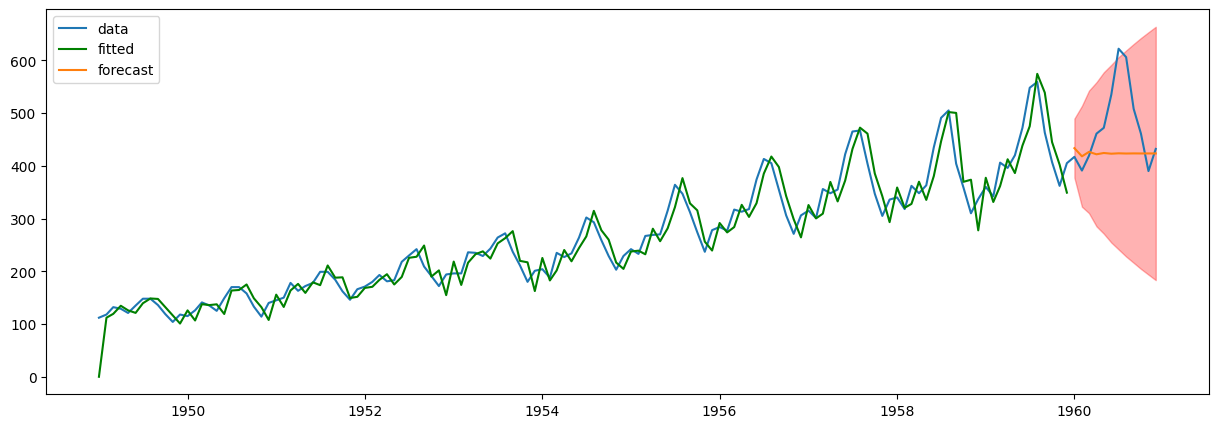

In [44]:
plot_fit_and_forecast(arima_result)

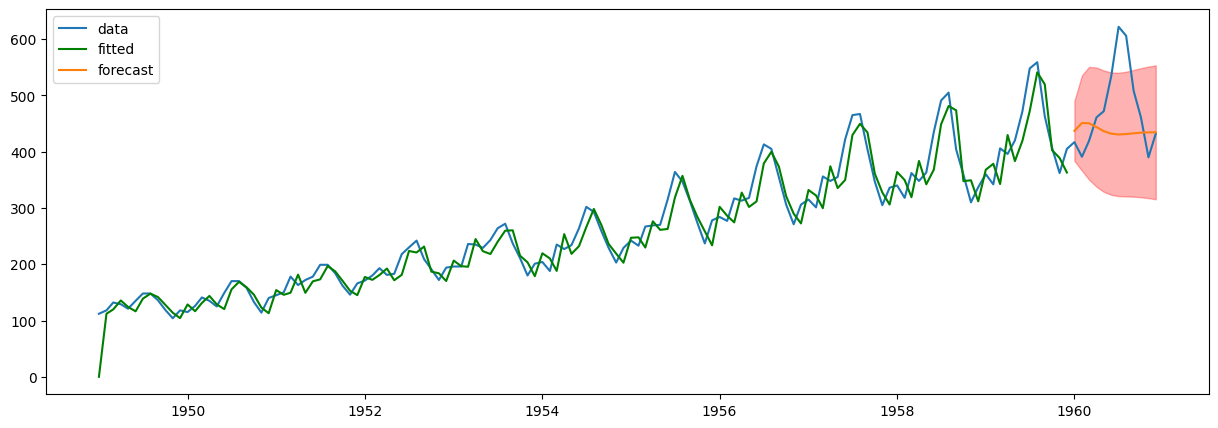

In [45]:
arima = ARIMA(train['Passengers'], order=(2,1,1))
arima_result = arima.fit()
plot_fit_and_forecast(arima_result)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


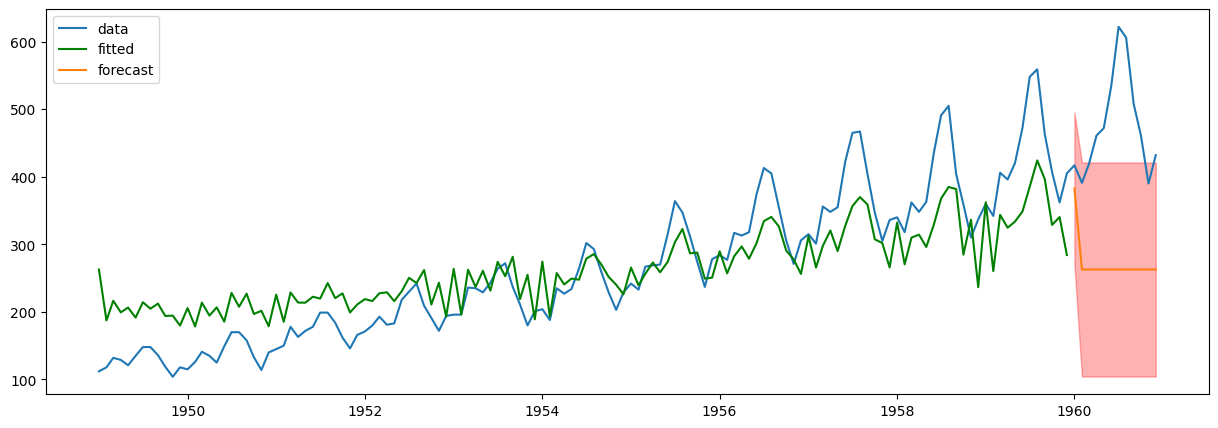

In [46]:
arima = ARIMA(train['Passengers'], order=(0,0,1))
arima_result = arima.fit()
plot_fit_and_forecast(arima_result)

In [47]:
df['Log1stDiff'] = df['1stdiff'].diff()

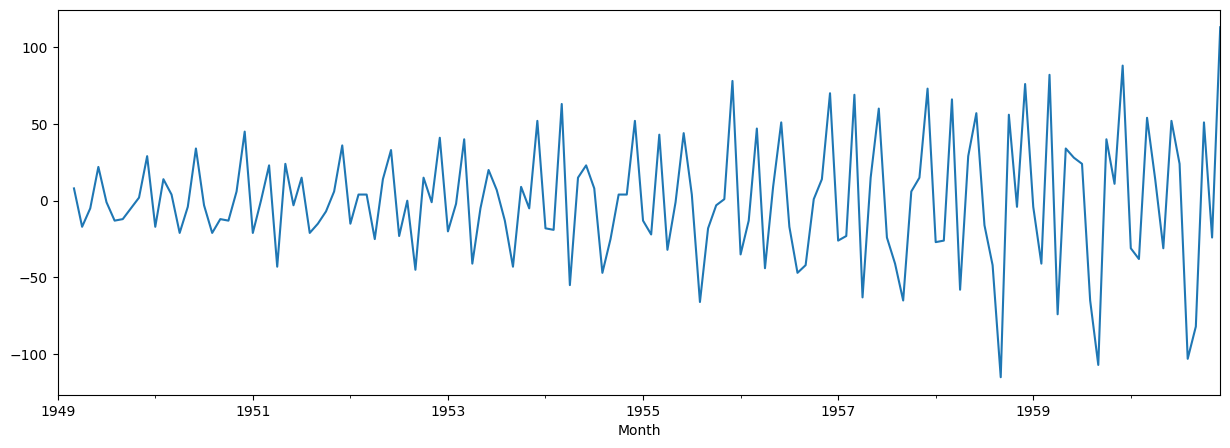

In [48]:
df['Log1stDiff'].plot(figsize=(15, 5));

first data: 1949-01-01 00:00:00
first train pred: DatetimeIndex(['1949-01-01', '1949-02-01'], dtype='datetime64[ns]', name='Month', freq='MS')


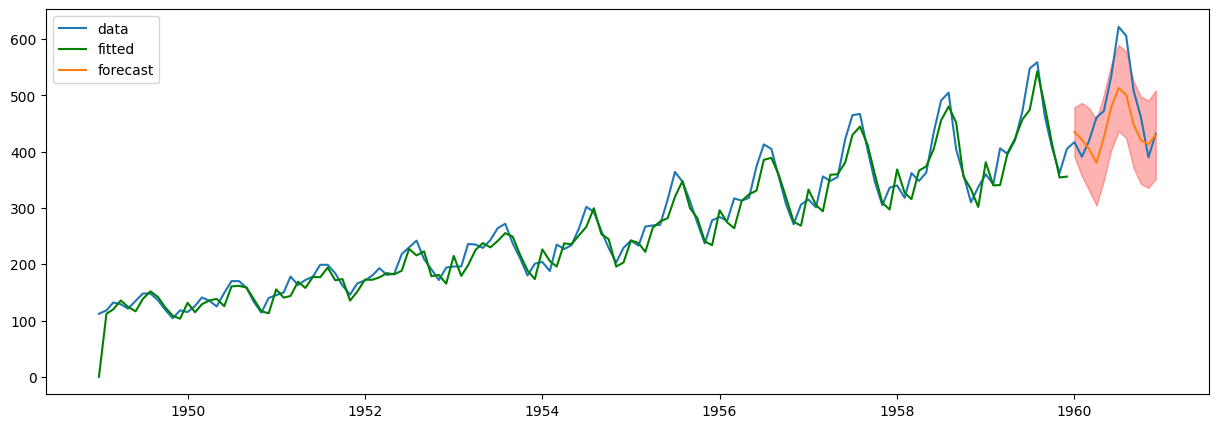

In [49]:
arima = ARIMA(train['Passengers'], order=(8,1,1))
arima_result_811 = arima.fit()

def plot_fit_and_forecast_int(result, d, col='Passengers'):
  fig, ax = plt.subplots(figsize=(15, 5))
  ax.plot(df[col], label='data')
  print("first data:", df.index[0])

  # plot the curve fitted on train set
  train_pred = result.predict(start=train.index[0], end=train.index[-1])
  print("first train pred:", train_pred.index[0:2])

  ax.plot(train_pred, color='green', label='fitted')

  # forecast the test set
  prediction_result = result.get_forecast(Ntest)
  conf_int = prediction_result.conf_int()
  lower, upper = conf_int['lower ' + col], conf_int['upper ' + col]
  forecast =  prediction_result.predicted_mean
  ax.plot(test.index, forecast, label='forecast')
  ax.fill_between(test.index, \
                  lower, upper, \
                  color='red', alpha=0.3)
  ax.legend()

plot_fit_and_forecast_int(arima_result_811, 1)

first data: 1949-01-01 00:00:00
first train pred: DatetimeIndex(['1949-01-01', '1949-02-01'], dtype='datetime64[ns]', name='Month', freq='MS')


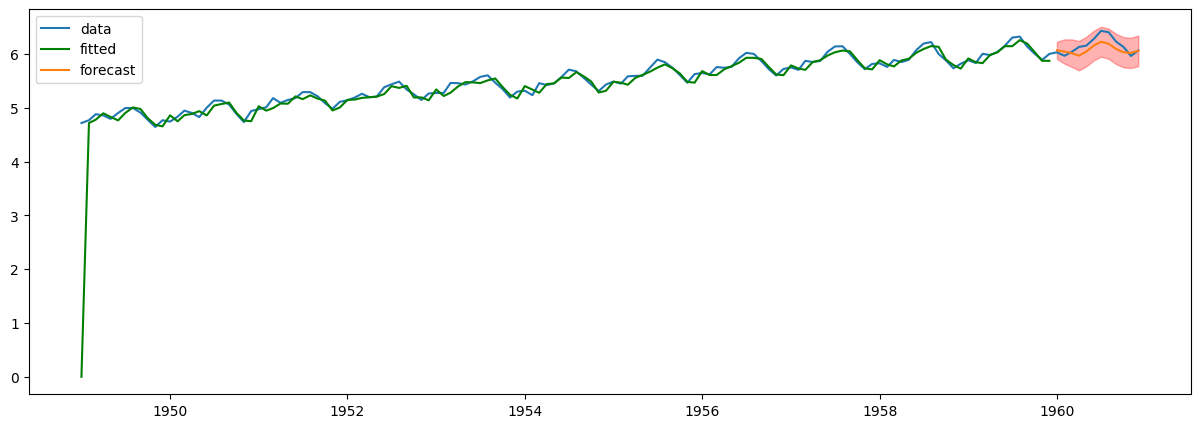

In [50]:
arima = ARIMA(train['LogPassengers'], order=(8,1,1))
arima_result_log811 = arima.fit()
plot_fit_and_forecast_int(arima_result_log811, 1, col='LogPassengers')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


first data: 1949-01-01 00:00:00
first train pred: DatetimeIndex(['1949-01-01', '1949-02-01'], dtype='datetime64[ns]', name='Month', freq='MS')


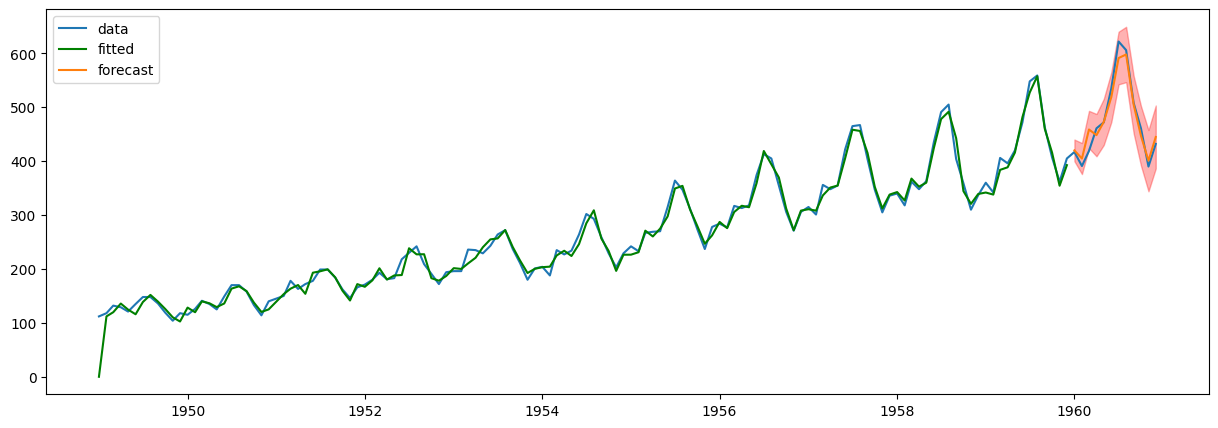

In [51]:
arima = ARIMA(train['Passengers'], order=(12,1,0))
arima_result_1210 = arima.fit()
plot_fit_and_forecast_int(arima_result_1210, 1, col='Passengers')

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


first data: 1949-01-01 00:00:00
first train pred: DatetimeIndex(['1949-01-01', '1949-02-01'], dtype='datetime64[ns]', name='Month', freq='MS')


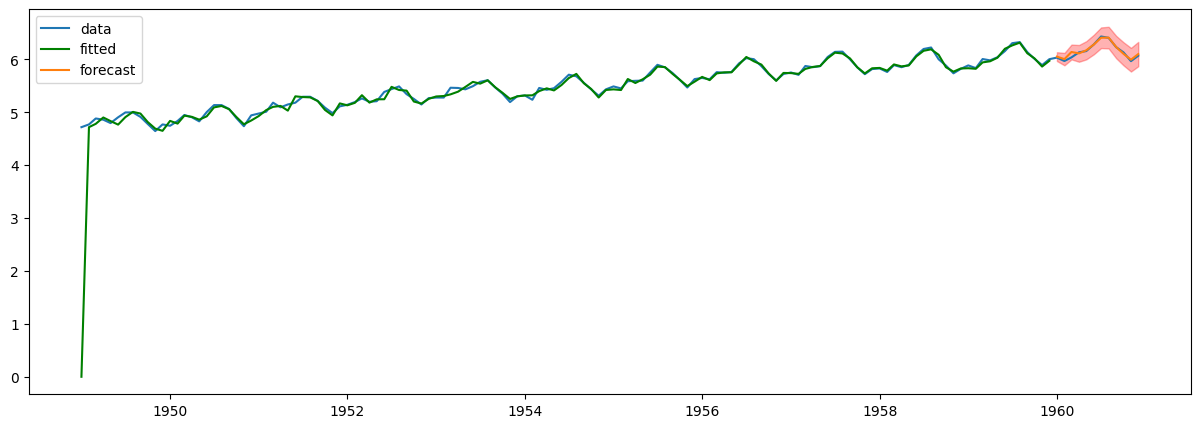

In [52]:
arima = ARIMA(train['LogPassengers'], order=(12,1,0))
arima_result_log1210 = arima.fit()
plot_fit_and_forecast_int(arima_result_log1210, 1, col='LogPassengers')

In [56]:
def rmse(result, is_logged):
  prediction_output = result.get_forecast(Ntest)
  forecast = prediction_output.predicted_mean
  if is_logged:
     forecast = np.exp(forecast)

  t = test['Passengers']
  y = forecast
  return np.sqrt(np.mean((t - y)**2))

In [57]:
print("ARIMA(8,1,1):", rmse(arima_result_811, False))
print("ARIMA(8,1,1) logged:", rmse(arima_result_log811, True))
print("ARIMA(12,1,0):", rmse(arima_result_1210, False))
print("ARIMA(12,1,0) logged:", rmse(arima_result_log1210, True))

ARIMA(8,1,1): 59.06459052741517
ARIMA(8,1,1) logged: 61.59740688711714
ARIMA(12,1,0): 17.5464070655406
ARIMA(12,1,0) logged: 16.107448748925506
